# Logical Fallacy Detection - Progress 3
**Dataset:** CoCoLoFa (Comments with Common Logical Fallacies)
https://github.com/Crowd-AI-Lab/cocolofa

**Progress 3:** Multiple improved models using TF-IDF:
- **Models:** Linear SVC, Complement Naive Bayes, XGBoost
- **Text Representation:** TF-IDF
- **Comparison:** All models + Progress 2 models (TF-IDF and Word2Vec)

**Citation:**
Min-Hsuan Yeh, Ruyuan Wan, and Ting-Hao 'Kenneth' Huang. (2024). *CoCoLoFa: A Dataset of News Comments with Common Logical Fallacies Written by LLM-Assisted Crowds*. [arXiv:2410.03457](https://arxiv.org/abs/2410.03457)

## 0. Import Libraries

In [1]:
import json
import re
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import ComplementNB
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, precision_recall_fscore_support
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Dataset

In [2]:
KAGGLE_PATH = '/kaggle/input/datasets/aristelcrowley/cocolofa'

if os.path.exists(KAGGLE_PATH):
    DATA_DIR = KAGGLE_PATH
    print(f"Running on Kaggle (dataset: {DATA_DIR})")
else:
    DATA_DIR = 'data'   
    print("Running locally")

# Load train data
file_path = os.path.join(DATA_DIR, 'train.json')
with open(file_path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)
    
records = []
for article in raw_data:
    for comment in article['comments']:
        records.append({
            'comment_id': comment['id'],
            'news_id': comment['news_id'],
            'fallacy': comment['fallacy'],
            'comment': comment['comment']
        })

df = pd.DataFrame(records)

# Load test data
with open(os.path.join(DATA_DIR, 'test.json'), 'r', encoding='utf-8') as f:
    test_raw = json.load(f)

test_records = []
for article in test_raw:
    for comment in article['comments']:
        test_records.append({
            'comment_id': comment['id'],
            'news_id': comment['news_id'],
            'fallacy': comment['fallacy'],
            'comment': comment['comment']
        })

df_test = pd.DataFrame(test_records)

print(f"Total train comments: {len(df)}")
print(f"Total test comments: {len(df_test)}")
print(f"\nDistribusi label fallacy (train):")
print(df['fallacy'].value_counts())

Running locally
Total train comments: 5370
Total test comments: 798

Distribusi label fallacy (train):
fallacy
none                        2202
slippery slope               431
appeal to worse problems     421
appeal to nature             412
appeal to tradition          401
false dilemma                391
appeal to majority           383
hasty generalization         379
appeal to authority          350
Name: count, dtype: int64


## 2. Text Cleaning

In [3]:
def clean_text(text):
    """Clean raw text."""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned'] = df['comment'].apply(clean_text)
df_test['cleaned'] = df_test['comment'].apply(clean_text)

print("Text cleaning complete.")

Text cleaning complete.


## 3. Tokenization

In [4]:
df['tokens'] = df['cleaned'].apply(word_tokenize)
df_test['tokens'] = df_test['cleaned'].apply(word_tokenize)

print("Tokenization complete.")

Tokenization complete.


## 4. Stopword Removal & Lemmatization

In [5]:
fallacy_indicators = {
    'everyone', 'always', 'never', 'must', 'should', 'all', 'every',
    'only', 'just', 'no', 'nothing', 'everything', 'most', 'any',
    'either', 'or', 'neither', 'nor', 'both', 'very', 'too',
}
stop_words = set(stopwords.words('english')) - fallacy_indicators
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [
        lemmatizer.lemmatize(token)
        for token in tokens
        if (token not in stop_words and len(token) > 2) or token in fallacy_indicators
    ]

df['lemmatized'] = df['tokens'].apply(lemmatize_tokens)
df_test['lemmatized'] = df_test['tokens'].apply(lemmatize_tokens)
df['processed_text'] = df['lemmatized'].apply(lambda x: ' '.join(x))
df_test['processed_text'] = df_test['lemmatized'].apply(lambda x: ' '.join(x))

print("Lemmatization complete.")

Lemmatization complete.


## 5. Label Encoding

In [6]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['fallacy'])
df_test['label'] = label_encoder.transform(df_test['fallacy'])

print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"\nLabel mapping:")
for i, cls in enumerate(label_encoder.classes_):
    count = (df['label'] == i).sum()
    print(f"  {i} → {cls} ({count} samples)")

Number of classes: 9

Label mapping:
  0 → appeal to authority (350 samples)
  1 → appeal to majority (383 samples)
  2 → appeal to nature (412 samples)
  3 → appeal to tradition (401 samples)
  4 → appeal to worse problems (421 samples)
  5 → false dilemma (391 samples)
  6 → hasty generalization (379 samples)
  7 → none (2202 samples)
  8 → slippery slope (431 samples)


## 6. Train/Validation/Test Split (80/10/10)

In [7]:
df_train, df_val = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df['label']
)

print(f"Train set size: {len(df_train)}")
print(f"Validation set size: {len(df_val)}")
print(f"Test set size: {len(df_test)}")

Train set size: 4564
Validation set size: 806
Test set size: 798


---
## 7. Text Representation: TF-IDF

In [8]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
)

X_train_tfidf = tfidf_vectorizer.fit_transform(df_train['processed_text'])
X_val_tfidf = tfidf_vectorizer.transform(df_val['processed_text'])
X_test_tfidf = tfidf_vectorizer.transform(df_test['processed_text'])

print(f"TF-IDF Matrix Shapes:")
print(f"  Train: {X_train_tfidf.shape}")
print(f"  Validation: {X_val_tfidf.shape}")
print(f"  Test: {X_test_tfidf.shape}")

TF-IDF Matrix Shapes:
  Train: (4564, 8000)
  Validation: (806, 8000)
  Test: (798, 8000)


In [9]:
y_train = df_train['label'].values
y_val = df_val['label'].values
y_test = df_test['label'].values

---
## 8. Load Progress 2 Models for Comparison

In [10]:
def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.wv.vector_size)
    return np.mean(vectors, axis=0)

In [11]:
# Load Progress 2 models
p2_logreg_tfidf = joblib.load('models/progress_2/logistic_regression_tfidf.joblib')
p2_logreg_w2v = joblib.load('models/progress_2/logistic_regression_w2v.joblib')
p2_tfidf_vectorizer = joblib.load('models/progress_2/tfidf_vectorizer.joblib')
p2_w2v_model = joblib.load('models/progress_2/word2vec_model.joblib')
p2_info = joblib.load('models/progress_2/preprocessing_info.joblib')

print("Progress 2 models loaded!")
print(f"  LogReg + TF-IDF   → F1: {p2_info['models']['logreg_tfidf']['f1_weighted']:.4f}")
print(f"  LogReg + Word2Vec → F1: {p2_info['models']['logreg_w2v']['f1_weighted']:.4f}")

Progress 2 models loaded!
  LogReg + TF-IDF   → F1: 0.6830
  LogReg + Word2Vec → F1: 0.5165


In [12]:
# Prepare P2 test data using P2's vectorizers
X_test_tfidf_p2 = p2_tfidf_vectorizer.transform(df_test['processed_text'])
X_test_w2v_p2 = np.array([document_vector(tokens, p2_w2v_model) for tokens in df_test['lemmatized']])

# Evaluate P2 models on test data
y_pred_p2_logreg_tfidf = p2_logreg_tfidf.predict(X_test_tfidf_p2)
y_pred_p2_logreg_w2v = p2_logreg_w2v.predict(X_test_w2v_p2)

print("Progress 2 models evaluated on test data.")

Progress 2 models evaluated on test data.


---
## 9. Model 1: Linear SVC

In [13]:
svc_base = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)
model_svc_tfidf = CalibratedClassifierCV(svc_base, cv=3)

print("Training Linear SVC...")
model_svc_tfidf.fit(X_train_tfidf, y_train)
print("Training complete!")

y_val_pred_svc = model_svc_tfidf.predict(X_val_tfidf)
val_f1_svc = f1_score(y_val, y_val_pred_svc, average='weighted')
print(f"Validation F1: {val_f1_svc:.4f}")

Training Linear SVC...
Training complete!
Validation F1: 0.6683


---
## 10. Model 2: Complement Naive Bayes

In [14]:
model_cnb_tfidf = ComplementNB(alpha=0.5)

print("Training Complement Naive Bayes...")
model_cnb_tfidf.fit(X_train_tfidf, y_train)
print("Training complete!")

y_val_pred_cnb = model_cnb_tfidf.predict(X_val_tfidf)
val_f1_cnb = f1_score(y_val, y_val_pred_cnb, average='weighted')
print(f"Validation F1: {val_f1_cnb:.4f}")

Training Complement Naive Bayes...
Training complete!
Validation F1: 0.6284


---
## 11. Model 3: XGBoost

In [15]:
model_xgb_tfidf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

print("Training XGBoost...")
model_xgb_tfidf.fit(X_train_tfidf, y_train)
print("Training complete!")

y_val_pred_xgb = model_xgb_tfidf.predict(X_val_tfidf)
val_f1_xgb = f1_score(y_val, y_val_pred_xgb, average='weighted')
print(f"Validation F1: {val_f1_xgb:.4f}")

Training XGBoost...
Training complete!
Validation F1: 0.6339


---
## 12. Test Evaluation - All Models

In [16]:
# Test predictions for all P3 models
y_test_pred_svc = model_svc_tfidf.predict(X_test_tfidf)
y_test_pred_cnb = model_cnb_tfidf.predict(X_test_tfidf)
y_test_pred_xgb = model_xgb_tfidf.predict(X_test_tfidf)

def get_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted'),
        'recall': recall_score(y_true, y_pred, average='weighted'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
        'f1_macro': f1_score(y_true, y_pred, average='macro')
    }

results = {
    # Progress 2 models
    'P2: LogReg + TF-IDF': get_metrics(y_test, y_pred_p2_logreg_tfidf),
    'P2: LogReg + W2V': get_metrics(y_test, y_pred_p2_logreg_w2v),
    # Progress 3 models
    'P3: Linear SVC': get_metrics(y_test, y_test_pred_svc),
    'P3: Complement NB': get_metrics(y_test, y_test_pred_cnb),
    'P3: XGBoost': get_metrics(y_test, y_test_pred_xgb),
}

print("Test evaluation complete!")

Test evaluation complete!


---
## 13. Complete Model Comparison

In [17]:
comparison_data = []
for model_name, metrics in results.items():
    progress = model_name.split(':')[0]
    model_desc = model_name.split(': ')[1]
    
    comparison_data.append({
        'Progress': progress,
        'Model': model_desc,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1 (weighted)': metrics['f1_weighted'],
        'F1 (macro)': metrics['f1_macro']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
comparison_df.index += 1

print("  PROGRESS 3 — Complete Model Comparison (P2 + P3, Ranked by Weighted F1)")
display(comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1 (weighted)': '{:.4f}',
    'F1 (macro)': '{:.4f}',
}).background_gradient(subset=['F1 (weighted)'], cmap='Greens'))

  PROGRESS 3 — Complete Model Comparison (P2 + P3, Ranked by Weighted F1)


,Progress,Model,Accuracy,Precision,Recall,F1 (weighted),F1 (macro)
1,P2,LogReg + TF-IDF,0.6855,0.6889,0.6855,0.6830,0.6979
2,P3,Linear SVC,0.6855,0.7036,0.6855,0.6704,0.6592
3,P3,XGBoost,0.6667,0.6848,0.6667,0.6467,0.6323
4,P3,Complement NB,0.6353,0.6326,0.6353,0.6269,0.6256
5,P2,LogReg + W2V,0.5263,0.5722,0.5263,0.5165,0.5623


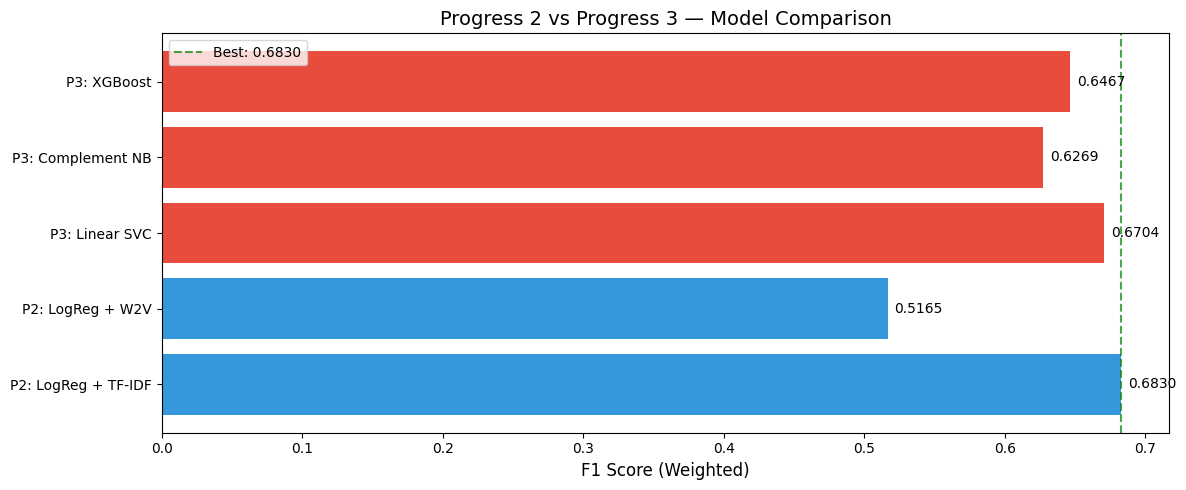

In [18]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 5))

model_names = list(results.keys())
f1_scores = [results[m]['f1_weighted'] for m in model_names]

colors = ['#3498db' if 'P2' in m else '#e74c3c' for m in model_names]
bars = ax.barh(model_names, f1_scores, color=colors)

ax.set_xlabel('F1 Score (Weighted)', fontsize=12)
ax.set_title('Progress 2 vs Progress 3 — Model Comparison', fontsize=14)
ax.axvline(x=max(f1_scores), color='green', linestyle='--', alpha=0.7, label=f'Best: {max(f1_scores):.4f}')

for bar, score in zip(bars, f1_scores):
    ax.text(score + 0.005, bar.get_y() + bar.get_height()/2, f'{score:.4f}', va='center', fontsize=10)

ax.legend()
plt.tight_layout()
plt.show()

## 14. Best Model Analysis

In [19]:
# Find best P3 model
p3_results = {k: v for k, v in results.items() if 'P3' in k}
best_p3_name = max(p3_results, key=lambda x: p3_results[x]['f1_weighted'])
best_p3_metrics = p3_results[best_p3_name]

# Get predictions for best model
pred_mapping = {
    'P3: Linear SVC': y_test_pred_svc,
    'P3: Complement NB': y_test_pred_cnb,
    'P3: XGBoost': y_test_pred_xgb,
}
best_pred = pred_mapping[best_p3_name]

print(f"  BEST PROGRESS 3 MODEL: {best_p3_name}")
print(f"\nTest Results:")
print(f"  Accuracy: {best_p3_metrics['accuracy']:.4f}")
print(f"  Precision: {best_p3_metrics['precision']:.4f}")
print(f"  Recall: {best_p3_metrics['recall']:.4f}")
print(f"  F1 (weighted): {best_p3_metrics['f1_weighted']:.4f}")
print(f"  F1 (macro): {best_p3_metrics['f1_macro']:.4f}")
print("\n" + classification_report(y_test, best_pred, target_names=label_encoder.classes_))

  BEST PROGRESS 3 MODEL: P3: Linear SVC

Test Results:
  Accuracy: 0.6855
  Precision: 0.7036
  Recall: 0.6855
  F1 (weighted): 0.6704
  F1 (macro): 0.6592

                          precision    recall  f1-score   support

     appeal to authority       0.77      0.54      0.63        56
      appeal to majority       0.86      0.71      0.78        59
        appeal to nature       0.84      0.87      0.86        55
     appeal to tradition       0.81      0.66      0.73        59
appeal to worse problems       0.79      0.64      0.71        64
           false dilemma       0.79      0.62      0.70        50
    hasty generalization       0.56      0.15      0.24        60
                    none       0.60      0.85      0.70       317
          slippery slope       0.76      0.49      0.59        78

                accuracy                           0.69       798
               macro avg       0.75      0.61      0.66       798
            weighted avg       0.70      0.69    

In [20]:
# Per-class F1 for best model
precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
    y_test, best_pred, average=None
)

per_class_df = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Support': support
}).sort_values('F1-Score', ascending=False)

print(f"  PER-CLASS F1 SCORES — {best_p3_name}")
display(per_class_df.style.format({
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'Support': '{:.0f}'
}).background_gradient(subset=['F1-Score'], cmap='Greens'))

  PER-CLASS F1 SCORES — P3: Linear SVC


,Class,Precision,Recall,F1-Score,Support
2,appeal to nature,0.8421,0.8727,0.8571,55
1,appeal to majority,0.8571,0.7119,0.7778,59
3,appeal to tradition,0.8125,0.6610,0.7290,59
4,appeal to worse problems,0.7885,0.6406,0.7069,64
7,none,0.6004,0.8486,0.7033,317
5,false dilemma,0.7949,0.6200,0.6966,50
0,appeal to authority,0.7692,0.5357,0.6316,56
8,slippery slope,0.7600,0.4872,0.5938,78
6,hasty generalization,0.5625,0.1500,0.2368,60


## 15. Confusion Matrices

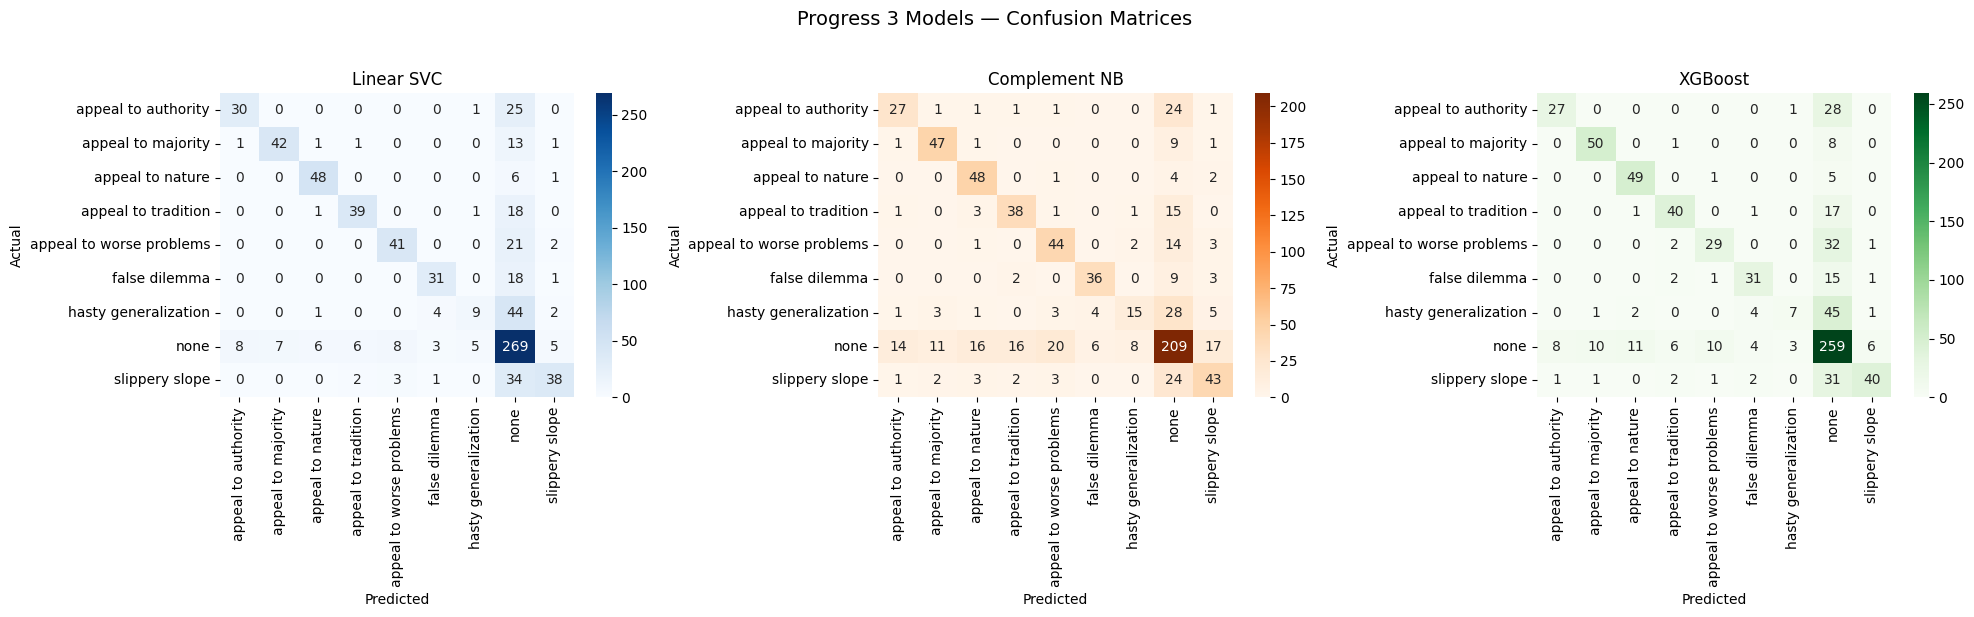

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cm_svc = confusion_matrix(y_test, y_test_pred_svc)
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[0].set_title('Linear SVC', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_cnb = confusion_matrix(y_test, y_test_pred_cnb)
sns.heatmap(cm_cnb, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[1].set_title('Complement NB', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[2].set_title('XGBoost', fontsize=12)
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('Progress 3 Models — Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 16. Save Models

In [22]:
os.makedirs('models/progress_3', exist_ok=True)

# Save all P3 models
joblib.dump(model_svc_tfidf, 'models/progress_3/linear_svc_tfidf.joblib')
joblib.dump(model_cnb_tfidf, 'models/progress_3/complement_nb_tfidf.joblib')
joblib.dump(model_xgb_tfidf, 'models/progress_3/xgboost_tfidf.joblib')

# Save vectorizer and encoder
joblib.dump(tfidf_vectorizer, 'models/progress_3/tfidf_vectorizer.joblib')
joblib.dump(label_encoder, 'models/progress_3/label_encoder.joblib')

# Save results info
p3_info = {
    'fallacy_indicators': list(fallacy_indicators),
    'models': {k: v for k, v in results.items() if k.startswith('P3:')},
    'best_model': best_p3_name
}
joblib.dump(p3_info, 'models/progress_3/preprocessing_info.joblib')

print("All models saved to models/progress_3/")
print("\nSaved files:")
for f in sorted(os.listdir('models/progress_3')):
    print(f"  - {f}")

All models saved to models/progress_3/

Saved files:
  - complement_nb_tfidf.joblib
  - label_encoder.joblib
  - linear_svc_tfidf.joblib
  - preprocessing_info.joblib
  - tfidf_vectorizer.joblib
  - xgboost_tfidf.joblib


## 17. Summary

In [23]:
print("  PROGRESS 3 SUMMARY")
print(f"\nNew Models: Linear SVC, Random Forest, Gradient Boosting")
print(f"Text Representation: TF-IDF")
print(f"\nData Split:")
print(f"  Train: {len(df_train)} samples")
print(f"  Validation: {len(df_val)} samples")
print(f"  Test: {len(df_test)} samples")
print(f"\nTest Results (F1 Weighted):")
print(f"  {'Model':<30} {'F1':>10}")
print(f"  {'-'*40}")
for name, metrics in sorted(results.items(), key=lambda x: x[1]['f1_weighted'], reverse=True):
    print(f"  {name:<30} {metrics['f1_weighted']:>10.4f}")
print(f"\nBest Progress 3 Model: {best_p3_name}")
print(f"  F1 (weighted): {best_p3_metrics['f1_weighted']:.4f}")
print(f"\nModels saved to: models/progress_3/")

  PROGRESS 3 SUMMARY

New Models: Linear SVC, Random Forest, Gradient Boosting
Text Representation: TF-IDF

Data Split:
  Train: 4564 samples
  Validation: 806 samples
  Test: 798 samples

Test Results (F1 Weighted):
  Model                                  F1
  ----------------------------------------
  P2: LogReg + TF-IDF                0.6830
  P3: Linear SVC                     0.6704
  P3: XGBoost                        0.6467
  P3: Complement NB                  0.6269
  P2: LogReg + W2V                   0.5165

Best Progress 3 Model: P3: Linear SVC
  F1 (weighted): 0.6704

Models saved to: models/progress_3/


---
## 18. Local Inference (Single Input)

Available models: `svc`, `rf`, `gb`

In [24]:
import joblib
import re
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Choose model: 'svc', 'cnb', 'xgb'
MODEL_CHOICE = 'svc'

model_files = {
    'svc': 'models/progress_3/linear_svc_tfidf.joblib',
    'cnb': 'models/progress_3/complement_nb_tfidf.joblib',
    'xgb': 'models/progress_3/xgboost_tfidf.joblib',
}

model = joblib.load(model_files[MODEL_CHOICE])
vectorizer = joblib.load('models/progress_3/tfidf_vectorizer.joblib')
label_encoder = joblib.load('models/progress_3/label_encoder.joblib')
info = joblib.load('models/progress_3/preprocessing_info.joblib')
fallacy_indicators = set(info['fallacy_indicators'])

stop_words = set(stopwords.words('english')) - fallacy_indicators
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if (token not in stop_words and len(token) > 2) or token in fallacy_indicators
    ]
    return ' '.join(tokens)

def predict_fallacy(text):
    processed = preprocess_text(text)
    features = vectorizer.transform([processed])
    prediction = model.predict(features)[0]
    return label_encoder.inverse_transform([prediction])[0]

# Test
test_text = "Everyone knows this is true. All experts agree."
result = predict_fallacy(test_text)
print(f"Model: {MODEL_CHOICE}")
print(f"Input: {test_text}")
print(f"Predicted fallacy: {result}")

Model: svc
Input: Everyone knows this is true. All experts agree.
Predicted fallacy: appeal to authority
